Data exploration for EB data

In [2]:
import scprep
import pandas as pd
import numpy as np
import scanpy as sc
import os

In [5]:
if os.getcwd().split("/")[-1] != "healthy_imm_expr":
    #set working directory to root of repository
    os.chdir("/lustre/scratch123/hgi/projects/healthy_imm_expr/t_generative/")
    print("Changed working directory to root of repository")

Changed working directory to root of repository


In [26]:
#download the dataset
download_path = f"{os.getcwd()}/data/"
print(download_path)

/lustre/scratch123/hgi/mdt1/projects/healthy_imm_expr/t_generative/data/


In [50]:
sparse=True
T1 = scprep.io.load_10X(os.path.join(download_path, "20240423_eb", "T0_1A"), sparse=sparse, gene_labels='both')
T2 = scprep.io.load_10X(os.path.join(download_path, "20240423_eb", "T2_3B"), sparse=sparse, gene_labels='both')
T3 = scprep.io.load_10X(os.path.join(download_path, "20240423_eb", "T4_5C"), sparse=sparse, gene_labels='both')
T4 = scprep.io.load_10X(os.path.join(download_path, "20240423_eb", "T6_7D"), sparse=sparse, gene_labels='both')
T5 = scprep.io.load_10X(os.path.join(download_path, "20240423_eb", "T8_9E"), sparse=sparse, gene_labels='both')

Pre-processing and filtering

<Axes: xlabel='Library size', ylabel='Number of cells'>

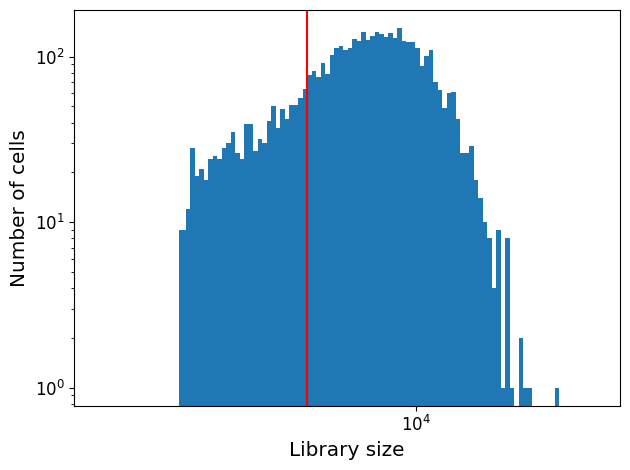

In [51]:
scprep.plot.plot_library_size(T1, percentile=20)

In [52]:
filtered_batches = []
for batch in [T1, T2, T3, T4, T5]:
    batch = scprep.filter.filter_library_size(batch, percentile=20, keep_cells='above')
    batch = scprep.filter.filter_library_size(batch, percentile=75, keep_cells='below')
    filtered_batches.append(batch)
del T1, T2, T3, T4, T5 # removes objects from memory

In [53]:
EBT_counts, sample_labels = scprep.utils.combine_batches(
    filtered_batches, 
    ["Day 00-03", "Day 06-09", "Day 12-15", "Day 18-21", "Day 24-27"],
    append_to_cell_names=True
)
del filtered_batches # removes objects from memory
EBT_counts.head()

,A1BG (ENSG00000121410),A1BG-AS1 (ENSG00000268895),A1CF (ENSG00000148584),A2M (ENSG00000175899),A2M-AS1 (ENSG00000245105),A2ML1 (ENSG00000166535),A2ML1-AS1 (ENSG00000256661),A2ML1-AS2 (ENSG00000256904),A3GALT2 (ENSG00000184389),A4GALT (ENSG00000128274),...,ZXDC (ENSG00000070476),ZYG11A (ENSG00000203995),ZYG11B (ENSG00000162378),ZYX (ENSG00000159840),ZZEF1 (ENSG00000074755),ZZZ3 (ENSG00000036549),bP-21264C1.2 (ENSG00000278932),bP-2171C21.3 (ENSG00000279501),bP-2189O9.3 (ENSG00000279579),hsa-mir-1253 (ENSG00000272920)
AAACATTGAAAGCA-1_Day 00-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGCAGAAA-1_Day 00-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGGAAGGC-1_Day 00-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGCACCGGTAT-1_Day 00-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGCACCTATTC-1_Day 00-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Filtering remove rare genes

In [54]:
EBT_counts = scprep.filter.filter_rare_genes(EBT_counts, min_cells=10)

In [55]:
EBT_counts_ = scprep.normalize.library_size_normalize(EBT_counts)

<Axes: xlabel='Gene expression', ylabel='Number of cells'>

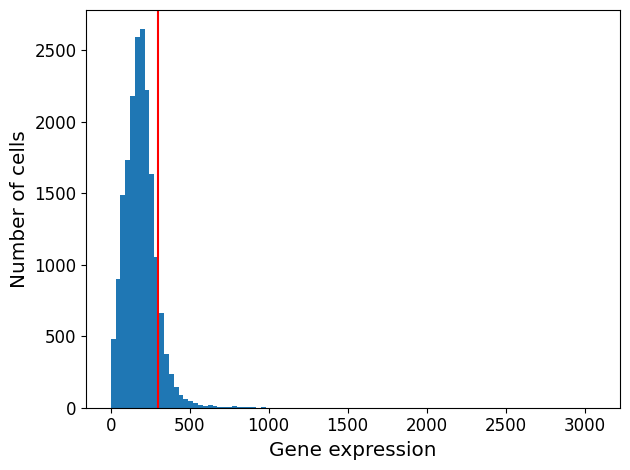

In [56]:
mito_genes = scprep.select.get_gene_set(EBT_counts_, starts_with="MT-") # Get all mitochondrial genes. There are 14, FYI.
scprep.plot.plot_gene_set_expression(EBT_counts_, genes=mito_genes, percentile=90)

In [57]:
EBT_counts_, sample_labels = scprep.filter.filter_gene_set_expression(
    EBT_counts_, sample_labels, genes=mito_genes, 
    percentile=90, keep_cells='below')

In [58]:
EBT_counts_

,A1BG (ENSG00000121410),A1BG-AS1 (ENSG00000268895),A2M (ENSG00000175899),A2M-AS1 (ENSG00000245105),A2ML1 (ENSG00000166535),A4GALT (ENSG00000128274),AAAS (ENSG00000094914),AACS (ENSG00000081760),AADAT (ENSG00000109576),AAED1 (ENSG00000158122),...,ZWILCH (ENSG00000174442),ZWINT (ENSG00000122952),ZXDA (ENSG00000198205),ZXDB (ENSG00000198455),ZXDC (ENSG00000070476),ZYG11A (ENSG00000203995),ZYG11B (ENSG00000162378),ZYX (ENSG00000159840),ZZEF1 (ENSG00000074755),ZZZ3 (ENSG00000036549)
AAACCGTGCAGAAA-1_Day 00-03,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AAACGCACCGGTAT-1_Day 00-03,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,1.046244,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AAACGCACCTATTC-1_Day 00-03,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,1.237011,0.0,0.0,0.0,0.0,0.0,1.237011,0.0,0.0
AAAGATCTCTGCTC-1_Day 00-03,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,1.830496,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AAAGATCTGGTACT-1_Day 00-03,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTTCTCA-1_Day 24-27,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,3.874467,0.0,0.0
TTTCTACTCTTATC-1_Day 24-27,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,4.076641,0.0,...,4.076641,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
TTTCTACTTGAGCT-1_Day 24-27,4.291845,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
TTTGCATGATGACC-1_Day 24-27,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [59]:
#filter EBT_counts based on EBT_counts_.index
EBT_counts_filtered = EBT_counts.loc[EBT_counts_.index, EBT_counts_.columns]

In [61]:
EBT_counts_filtered

,A1BG (ENSG00000121410),A1BG-AS1 (ENSG00000268895),A2M (ENSG00000175899),A2M-AS1 (ENSG00000245105),A2ML1 (ENSG00000166535),A4GALT (ENSG00000128274),AAAS (ENSG00000094914),AACS (ENSG00000081760),AADAT (ENSG00000109576),AAED1 (ENSG00000158122),...,ZWILCH (ENSG00000174442),ZWINT (ENSG00000122952),ZXDA (ENSG00000198205),ZXDB (ENSG00000198455),ZXDC (ENSG00000070476),ZYG11A (ENSG00000203995),ZYG11B (ENSG00000162378),ZYX (ENSG00000159840),ZZEF1 (ENSG00000074755),ZZZ3 (ENSG00000036549)
AAACCGTGCAGAAA-1_Day 00-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGCACCGGTAT-1_Day 00-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGCACCTATTC-1_Day 00-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
AAAGATCTCTGCTC-1_Day 00-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAGATCTGGTACT-1_Day 00-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTTCTCA-1_Day 24-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
TTTCTACTCTTATC-1_Day 24-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTCTACTTGAGCT-1_Day 24-27,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGCATGATGACC-1_Day 24-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [117]:
#create anndata object
adata = sc.AnnData(
    X=EBT_counts_filtered.values
)
adata.obs_names = EBT_counts_filtered.index
adata.var_names = EBT_counts_filtered.columns

In [118]:
#str manipulation
adata.obs['Barcode'] = adata.obs_names.str.split("_").str[0]
adata.obs['Timepoint'] = adata.obs_names.str.split("_").str[1]
adata.obs_names = adata.obs['Barcode']
adata.obs_names.name = None
adata.var['gene_name'] = adata.var_names.str.split(' ').str[0]
adata.var['ensembl_id'] = adata.var_names.str.split(' ').str[1]
adata.var['ensembl_id'] = adata.var['ensembl_id'].str.strip('()')
adata.var_names = adata.var['gene_name']
adata.var_names.name = None

In [119]:
#save adata object
adata.write("./data/20240423_eb/EB.h5ad")